In [1]:
# Tourism Development in the Russian Far East
## Cluster Analysis for 11 Federal Subjects of the Far Eastern Federal District

### 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt

In [8]:
### 2. Upload Data File
#### This cell uploads the Excel file containing tourism statistics for the 11 regions of the Far Eastern Federal District to the Colab environment.

from google.colab import files

uploaded = files.upload()


Saving Tourism_Cluster_DFO_2023.xlsx to Tourism_Cluster_DFO_2023 (1).xlsx


In [9]:
### 3. Load and Explore Data
#### This cell loads the tourism statistics from the uploaded Excel file and displays an overview of the dataset.
df = pd.read_excel(
    "Tourism_Cluster_DFO_2023.xlsx",
    sheet_name="Tourism_2023"
)

df

,Region_ID,Region_EN,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
0,1,Republic of Buryatia,508,564,46,6.0,7.6,5.3,263,401,269578,61265
1,2,Republic of Sakha (Yakutia),211,235,74,15.0,21.2,14.1,242,500,353740,109466
2,3,Zabaykalsky Krai,215,382,27,9.4,1.3,17.9,276,324,244239,72320
3,4,Kamchatka Krai,111,228,114,13.1,16.3,5.3,271,548,101193,33405
4,5,Primorsky Krai,628,1231,118,49.9,15.1,54.0,318,235,646506,210225
5,6,Khabarovsk Krai,227,699,113,27.4,26.8,29.4,246,302,466944,161163
6,7,Amur Oblast,194,354,59,16.6,4.8,23.5,172,546,267573,60872
7,8,Magadan Oblast,27,125,7,0.9,0.3,1.6,350,196,48751,16213
8,9,Sakhalin Oblast,117,245,38,9.4,11.9,6.1,246,1077,207434,57831
9,10,Jewish Autonomous Oblast,31,45,5,0.0,0.0,1.4,138,180,37876,11651


=== Indicator columns ===
['Region_ID', 'Collective_Accommodation', 'Collective_Tourists', 'Tour_Firms', 'Tour_Packages', 'Domestic_Tourists_By_Firms', 'Outbound_Tourists_By_Firms', 'Theater_Visitors_per_1000', 'Museum_Visits_per_1000', 'Retail_Turnover_2023', 'Paid_Services_2023']

=== First 5 rows of numeric data ===
   Region_ID  Collective_Accommodation  Collective_Tourists  Tour_Firms  \
0          1                       508                  564          46   
1          2                       211                  235          74   
2          3                       215                  382          27   
3          4                       111                  228         114   
4          5                       628                 1231         118   

   Tour_Packages  Domestic_Tourists_By_Firms  Outbound_Tourists_By_Firms  \
0            6.0                         7.6                         5.3   
1           15.0                        21.2                        14.1   


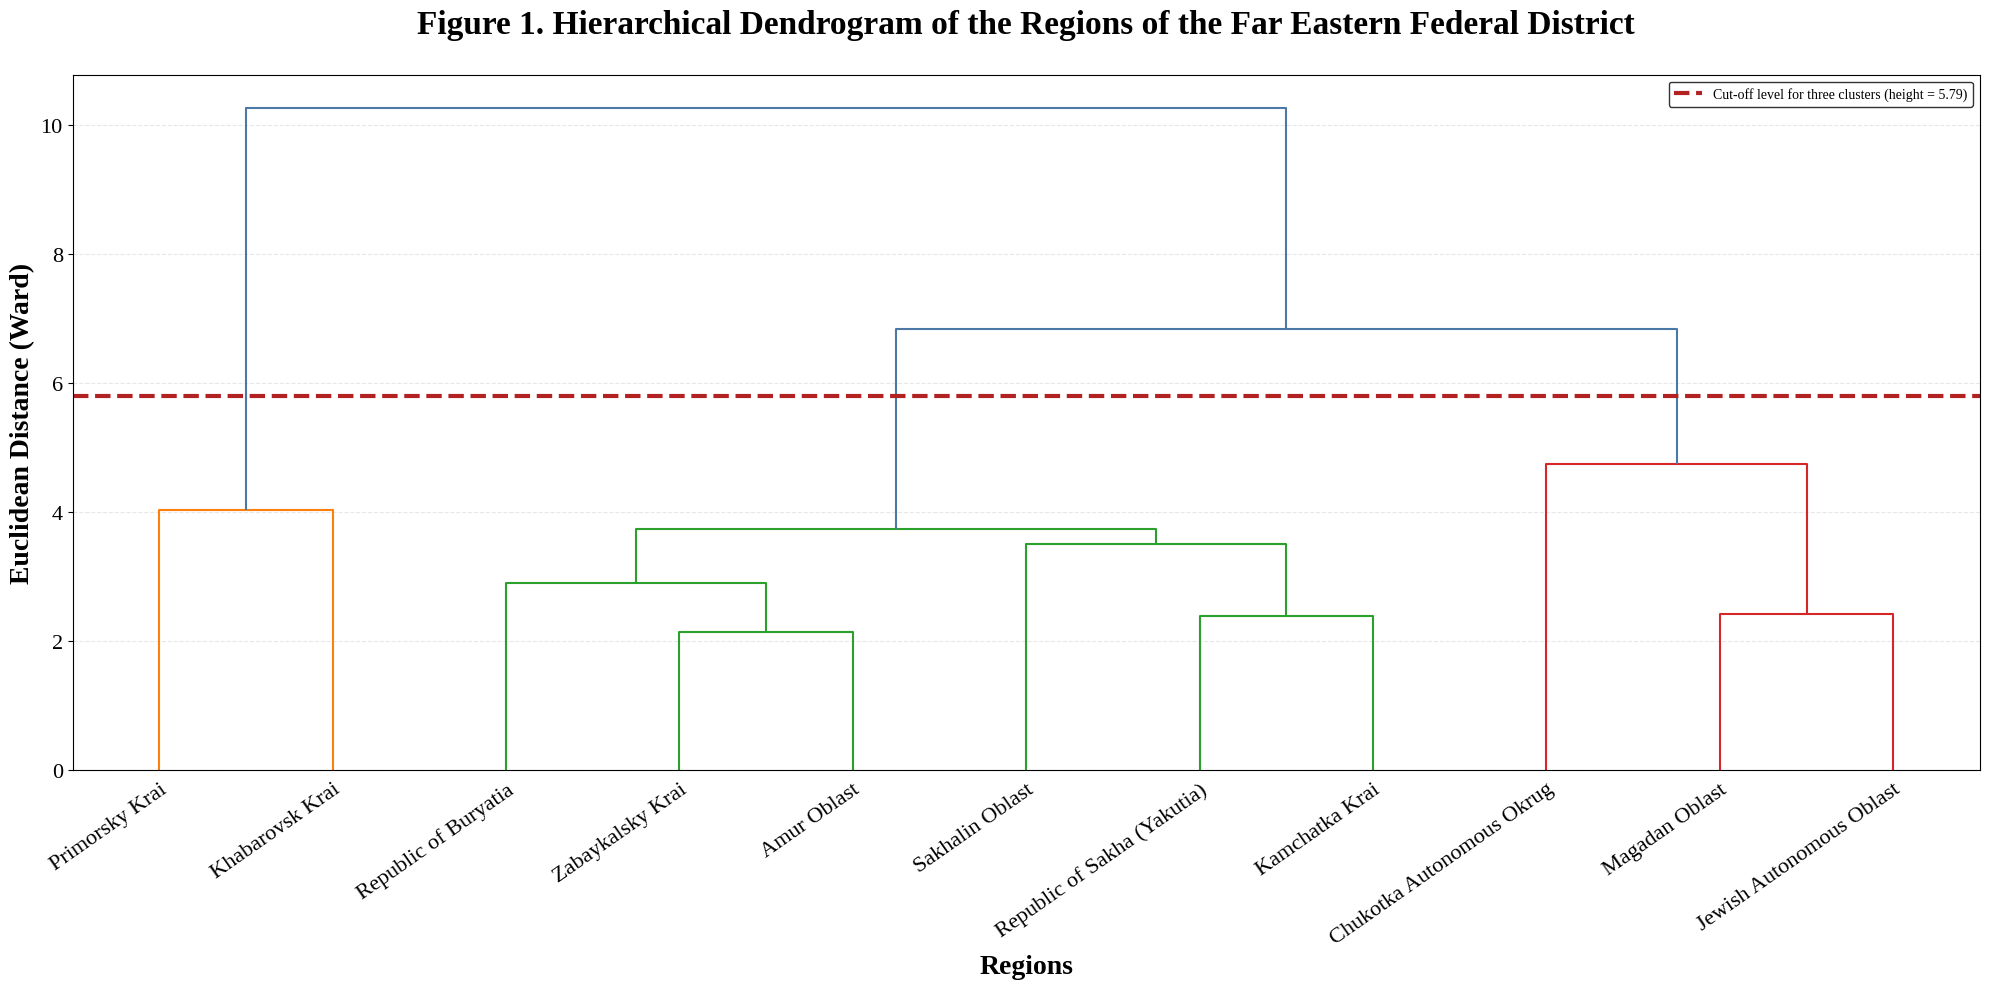


LIST OF 11 REGIONS (in order of appearance on the dendrogram):
1. Republic of Buryatia
2. Republic of Sakha (Yakutia)
3. Zabaykalsky Krai
4. Kamchatka Krai
5. Primorsky Krai
6. Khabarovsk Krai
7. Amur Oblast
8. Magadan Oblast
9. Sakhalin Oblast
10. Jewish Autonomous Oblast
11. Chukotka Autonomous Okrug

WARD CLUSTERING RESULTS (3 clusters):

Cluster 1: 2 regions
  - Primorsky Krai
  - Khabarovsk Krai

Cluster 2: 6 regions
  - Republic of Buryatia
  - Republic of Sakha (Yakutia)
  - Zabaykalsky Krai
  - Kamchatka Krai
  - Amur Oblast
  - Sakhalin Oblast

Cluster 3: 3 regions
  - Magadan Oblast
  - Jewish Autonomous Oblast
  - Chukotka Autonomous Okrug


In [11]:
# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# === Install Liberation Serif font ===
!apt-get install fonts-liberation -y > /dev/null 2>&1
plt.rcParams['font.family'] = 'Liberation Serif'

# ======================================================
# 2. LOAD DATA CORRECTLY
# ======================================================
# Read the sheet without setting index_col=0 immediately to avoid confusion
df_temp = pd.read_excel('Tourism_Cluster_DFO_2023.xlsx', sheet_name='Tourism_2023', header=0)

# Extract region names (Region_EN column) and set as index
regions = df_temp['Region_EN'].values
df = df_temp.drop(columns=['Region_EN'])

# Now df contains only numeric columns (10 indicators)
indicators = df.columns.tolist()
X = df.values  # all numeric

print("=== Indicator columns ===")
print(indicators)
print("\n=== First 5 rows of numeric data ===")
print(df.head())
print("\nShape of X:", X.shape)  # Should be (11, 10)

# ======================================================
# 3. DATA STANDARDIZATION
# ======================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n=== Standardized data (first 5 regions) ===")
print(pd.DataFrame(X_scaled, index=regions, columns=indicators).head())

# ======================================================
# 4. HIERARCHICAL CLUSTERING (WARD)
# ======================================================
linked = linkage(X_scaled, method='ward')

# Calculate cut height for 3 clusters
cut_height = (linked[-3, 2] + linked[-2, 2]) / 2

# ======================================================
# 5. PLOT DENDROGRAM
# ======================================================
fig, ax = plt.subplots(figsize=(20, 10))

dendrogram(
    linked,
    labels=regions,                     # This is the list of 11 region names
    leaf_rotation=35,
    leaf_font_size=16,
    color_threshold=cut_height,
    above_threshold_color="#4C78A8",
    ax=ax
)

# --- Cluster cut-off line ---
ax.axhline(
    y=cut_height,
    color="#B22222",
    linestyle="--",
    linewidth=3.0,
    label=f"Cut-off level for three clusters (height = {cut_height:.2f})"
)

# --- Title ---
ax.set_title(
    "Figure 1. Hierarchical Dendrogram of the Regions of the Far Eastern Federal District",
    fontsize=24,
    fontweight="bold",
    pad=30,
    fontname='Liberation Serif'
)

# --- Axis labels ---
ax.set_xlabel("Regions", fontsize=20, fontweight="bold", fontname='Liberation Serif')
ax.set_ylabel("Euclidean Distance (Ward)", fontsize=20, fontweight="bold", fontname='Liberation Serif')

# --- Format X-axis labels (region names) ---
plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
    rotation_mode="anchor",
    fontsize=16,
    fontname='Liberation Serif'
)

# --- Format Y-axis numbers ---
ax.tick_params(axis="y", labelsize=16)

# --- Legend ---
ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=15,
    edgecolor="black",
    facecolor="white",
    prop={'family': 'Liberation Serif'}
)

# --- Grid ---
ax.grid(axis="y", linestyle="--", alpha=0.3)

# --- Adjust layout ---
plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

# --- Save images ---
plt.savefig("dendrogram.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("dendrogram.pdf", bbox_inches="tight", facecolor="white")

plt.show()

# ======================================================
# 6. CHECK CLUSTER LABELS AND REGION LIST
# ======================================================
print("\n" + "="*60)
print("LIST OF 11 REGIONS (in order of appearance on the dendrogram):")
print("="*60)
for i, r in enumerate(regions):
    print(f"{i+1}. {r}")

# Assign cluster labels based on cut-off
cluster_labels = fcluster(linked, t=3, criterion='maxclust')

print("\n" + "="*60)
print("WARD CLUSTERING RESULTS (3 clusters):")
print("="*60)
for cluster_id in sorted(set(cluster_labels)):
    members = [regions[i] for i in range(len(regions)) if cluster_labels[i] == cluster_id]
    print(f"\nCluster {cluster_id}: {len(members)} regions")
    for m in members:
        print(f"  - {m}")

In [12]:
# ======================================================
# 11. DOWNLOAD FILES TO LOCAL MACHINE
# ======================================================
from google.colab import files

# Download PNG file
files.download("dendrogram.png")

# Download PDF file (if needed)
files.download("dendrogram.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ============================================================================
# CLUSTER ANALYSIS - FINAL VERSION
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. LOAD DATA
# ============================================================================
# Note: The Excel file should already be uploaded to the Colab environment
df = pd.read_excel('Tourism_Cluster_DFO_2023.xlsx', sheet_name='Tourism_2023')
print("✅ Data loaded successfully!")

# Extract feature columns (all columns except Region_ID and Region_EN)
feature_cols = df.columns[2:].tolist()
X = df[feature_cols].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df['Region_EN'])

# ============================================================================
# 2. K-MEANS CLUSTERING (k=3)
# ============================================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=100, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate centroids and determine cluster ranking
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
avg_score = centroids.mean(axis=1)
cluster_rank = avg_score.sort_values(ascending=False).index.tolist()
cluster_names_map = {
    cluster_rank[0]: "Leading",
    cluster_rank[1]: "Intermediate",
    cluster_rank[2]: "Peripheral"
}

df['Cluster_Num'] = kmeans_labels
df['Cluster_Name'] = df['Cluster_Num'].map(cluster_names_map)

print("\n" + "="*80)
print("✅ K-MEANS CLUSTERING RESULTS (3 CLUSTERS)")
print("="*80)
print(df[['Region_EN', 'Cluster_Name']].sort_values('Cluster_Name').to_string(index=False))

# ============================================================================
# 3. APPENDIX A: Z-SCORE CENTROIDS
# ============================================================================
df_scaled_with_name = df_scaled.copy()
df_scaled_with_name['Cluster_Name'] = df['Cluster_Name'].values
centroids_df = df_scaled_with_name.groupby('Cluster_Name').mean()
centroids_df = centroids_df.reindex(['Leading', 'Intermediate', 'Peripheral'])

print("\n" + "="*80)
print("📊 APPENDIX A: Z-SCORE CENTROIDS (CLUSTER MEANS)")
print("="*80)
print(centroids_df.round(2).to_string())

# ============================================================================
# 4. TABLE 2: VALIDATION METRICS
# ============================================================================
metrics_data = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=300)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    metrics_data.append([k, round(sil, 3), round(ch, 2), round(db, 3)])

df_metrics = pd.DataFrame(metrics_data, columns=['k', 'Silhouette', 'CH Index', 'DB Index'])

print("\n" + "="*80)
print("📋 TABLE 2: VALIDATION METRICS (k=2 -> 5)")
print("="*80)
print(df_metrics.to_string(index=False))

# ============================================================================
# 5. APPENDIX B.1: ANOVA
# ============================================================================
anova_results = []
for i, col in enumerate(feature_cols):
    group0 = X_scaled[df['Cluster_Num'] == 0, i]
    group1 = X_scaled[df['Cluster_Num'] == 1, i]
    group2 = X_scaled[df['Cluster_Num'] == 2, i]
    f_stat, p_val = f_oneway(group0, group1, group2)
    anova_results.append([col, round(f_stat, 2), round(p_val, 4)])

df_anova = pd.DataFrame(anova_results, columns=['Indicator', 'F-statistic', 'p-value'])

print("\n" + "="*80)
print("📊 APPENDIX B.1: ANOVA COMPARING 3 CLUSTERS")
print("="*80)
print(df_anova.to_string(index=False))

# ============================================================================
# 6. APPENDIX B.2: TUKEY HSD POST-HOC
# ============================================================================
print("\n" + "="*80)
print("📊 APPENDIX B.2: TUKEY HSD - PAIRWISE COMPARISONS")
print("="*80)

for i, col in enumerate(feature_cols):
    data_for_test = X_scaled[:, i]
    tukey = pairwise_tukeyhsd(endog=data_for_test, groups=df['Cluster_Num'], alpha=0.05)
    print(f"\n--- {col} ---")
    print(tukey.summary())

# ============================================================================
# 7. APPENDIX C: ROBUSTNESS CHECKS
# ============================================================================
# Ward vs K-means (Adjusted Rand Index)
dist_matrix = pdist(X_scaled, metric='euclidean')
ward_linkage = linkage(dist_matrix, method='ward')
ward_labels = fcluster(ward_linkage, t=3, criterion='maxclust')
ari_ward_kmeans = adjusted_rand_score(ward_labels, kmeans_labels)

# Block-balanced sensitivity analysis
block1 = ['Collective_Accommodation', 'Collective_Tourists']
block2 = ['Tour_Firms', 'Tour_Packages', 'Domestic_Tourists_By_Firms', 'Outbound_Tourists_By_Firms']
block3 = ['Theater_Visitors_per_1000', 'Museum_Visits_per_1000']
block4 = ['Retail_Turnover_2023', 'Paid_Services_2023']
blocks = [block1, block2, block3, block4]

block_scores = []
for b in blocks:
    idxs = [feature_cols.index(col) for col in b]
    block_mean = np.mean(X_scaled[:, idxs], axis=1)
    block_scores.append(block_mean)

block_matrix = np.column_stack(block_scores)
block_scaled = StandardScaler().fit_transform(block_matrix)
kmeans_block = KMeans(n_clusters=3, random_state=42, n_init=100)
block_labels = kmeans_block.fit_predict(block_scaled)
ari_block = adjusted_rand_score(kmeans_labels, block_labels)
sil_block = silhouette_score(block_scaled, block_labels)

print("\n" + "="*80)
print("📊 APPENDIX C: ROBUSTNESS CHECKS")
print("="*80)
print(f"Adjusted Rand Index (Ward vs K-means) = {ari_ward_kmeans:.2f}")
print(f"Adjusted Rand Index (original vs block) = {ari_block:.2f}")
print(f"Silhouette (block, k=3) = {round(sil_block, 3)}")

print("\n" + "="*80)
print("✅ ALL ANALYSES COMPLETED SUCCESSFULLY!")
print("="*80)

✅ Data loaded successfully!

✅ K-MEANS CLUSTERING RESULTS (3 CLUSTERS)
                  Region_EN Cluster_Name
       Republic of Buryatia Intermediate
Republic of Sakha (Yakutia) Intermediate
           Zabaykalsky Krai Intermediate
             Kamchatka Krai Intermediate
                Amur Oblast Intermediate
            Sakhalin Oblast Intermediate
             Primorsky Krai      Leading
            Khabarovsk Krai      Leading
             Magadan Oblast   Peripheral
   Jewish Autonomous Oblast   Peripheral
  Chukotka Autonomous Okrug   Peripheral

📊 APPENDIX A: Z-SCORE CENTROIDS (CLUSTER MEANS)
              Collective_Accommodation  Collective_Tourists  Tour_Firms  Tour_Packages  Domestic_Tourists_By_Firms  Outbound_Tourists_By_Firms  Theater_Visitors_per_1000  Museum_Visits_per_1000  Retail_Turnover_2023  Paid_Services_2023
Cluster_Name                                                                                                                                            